In [1]:
import sys
!{sys.executable} -m pip install -U torch torchvision opencv-python scikit-learn matplotlib seaborn pandas tqdm


In [5]:
import os, json, random, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from ultralytics import YOLO

# ---- Reproducibility ----
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# ---- CUDA stability fixes (from your earlier TDR / broken-context debugging) ----
torch.backends.cudnn.benchmark = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [7]:
CONFIG = {
    # --- Stage 1 (detector) ---
    "yaml_path": r"C:\Users\ROG\Desktop\Datasets_with_annotation_object_detection\Merged_dataset\data.yaml",
    "stage1_weights": r"C:\Users\ROG\runs\obb\runs_obb\obb_s_832_ep150\weights\best.pt",
    "det_imgsz": 832,
    "det_conf": 0.25,          # use your best_conf from the threshold sweep if you have it

    # --- Raw dataset (Stage 1 image/label layout) ---
    "images_root": r"C:\Users\ROG\Desktop\Datasets_with_annotation_object_detection\Merged_dataset\images",
    "labels_root": r"C:\Users\ROG\Desktop\Datasets_with_annotation_object_detection\Merged_dataset\labels",

    # --- Stage 2 (classification crops) ---
    "stage2_root": r"C:\Users\ROG\Desktop\Datasets_with_annotation_object_detection\Stage2_Crops",
    "crop_size": 260,           # EfficientNet-B2 native resolution
    "class_names": ["Interphase", "Prophase", "Lateprophase", "Metaphase",
                     "Anaphase", "Lateanaphase", "Telophase"],

    # --- Training ---
    "batch_size": 16,
    "epochs": 40,
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "checkpoint_dir": r"C:\Users\ROG\runs_cls\effnet_b2_focal",
    "resume": True,
}

os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
CLASS_NAMES = CONFIG["class_names"]
NUM_CLASSES = len(CLASS_NAMES)
print(f"{NUM_CLASSES} classes: {CLASS_NAMES}")


7 classes: ['Interphase', 'Prophase', 'Lateprophase', 'Metaphase', 'Anaphase', 'Lateanaphase', 'Telophase']


In [9]:
def rotate_and_crop(image, cx, cy, w, h, angle_rad, out_size=260, pad=6):
    """
    Rotate `image` so the box (cx, cy, w, h, angle_rad) becomes axis-aligned,
    crop it out, and resize to (out_size, out_size).

    angle_rad: rotation of the box in radians (Ultralytics OBB convention).
    pad: extra pixels of margin kept around the box before resizing, so cell
         boundaries aren't clipped.
    """
    H, W = image.shape[:2]
    angle_deg = np.degrees(angle_rad)

    # Rotate the *whole* image around the box center so the box becomes upright.
    M = cv2.getRotationMatrix2D((float(cx), float(cy)), angle_deg, 1.0)
    rotated = cv2.warpAffine(image, M, (W, H), flags=cv2.INTER_LINEAR,
                              borderMode=cv2.BORDER_REPLICATE)

    half_w, half_h = w / 2 + pad, h / 2 + pad
    x1, y1 = int(round(cx - half_w)), int(round(cy - half_h))
    x2, y2 = int(round(cx + half_w)), int(round(cy + half_h))

    # Clip to image bounds
    x1c, y1c = max(0, x1), max(0, y1)
    x2c, y2c = min(W, x2), min(H, y2)
    crop = rotated[y1c:y2c, x1c:x2c]

    if crop.size == 0:
        return None

    # Pad back out if clipping shrank the box (keeps aspect sane near image edges)
    top, bottom = y1c - y1, y2 - y2c
    left, right = x1c - x1, x2 - x2c
    if top or bottom or left or right:
        crop = cv2.copyMakeBorder(crop, max(top, 0), max(bottom, 0),
                                   max(left, 0), max(right, 0),
                                   cv2.BORDER_REPLICATE)

    crop = cv2.resize(crop, (out_size, out_size), interpolation=cv2.INTER_AREA)
    return crop


def obb_label_to_xywhr(points_px):
    """
    points_px: (4, 2) array of pixel-space polygon corners from a YOLO-OBB label line.
    Returns (cx, cy, w, h, angle_rad) using the same convention as result.obb.xywhr.
    """
    rect = cv2.minAreaRect(points_px.astype(np.float32))   # ((cx,cy),(w,h),angle_deg)
    (cx, cy), (w, h), angle_deg = rect
    return cx, cy, w, h, np.radians(angle_deg)


In [11]:
def build_stage2_split(split, cfg=CONFIG):
    img_dir = Path(cfg["images_root"]) / split
    lbl_dir = Path(cfg["labels_root"]) / split
    out_dir = Path(cfg["stage2_root"]) / split
    for cname in cfg["class_names"]:
        (out_dir / cname).mkdir(parents=True, exist_ok=True)

    img_paths = sorted([p for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")
                         for p in img_dir.glob(ext)])

    n_crops, n_skipped = 0, 0
    for img_path in img_paths:
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if not lbl_path.exists():
            continue
        image = cv2.imread(str(img_path))
        if image is None:
            continue
        H, W = image.shape[:2]

        with open(lbl_path, "r") as f:
            lines = [ln.strip() for ln in f if ln.strip()]

        for i, line in enumerate(lines):
            parts = line.split()
            cls_id = int(float(parts[0]))
            coords = np.array(parts[1:9], dtype=np.float32).reshape(4, 2)
            coords[:, 0] *= W
            coords[:, 1] *= H

            cx, cy, w, h, angle_rad = obb_label_to_xywhr(coords)
            crop = rotate_and_crop(image, cx, cy, w, h, angle_rad, out_size=cfg["crop_size"])
            if crop is None:
                n_skipped += 1
                continue

            cname = cfg["class_names"][cls_id]
            out_path = out_dir / cname / f"{img_path.stem}_{i:02d}.jpg"
            cv2.imwrite(str(out_path), crop)
            n_crops += 1

    print(f"[{split}] wrote {n_crops} crops, skipped {n_skipped}")


for split in ["train", "val", "test"]:
    build_stage2_split(split)


[train] wrote 10018 crops, skipped 0
[val] wrote 2188 crops, skipped 0
[test] wrote 1402 crops, skipped 0


In [13]:
IMG_SIZE = CONFIG["crop_size"]
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

stage2_root = CONFIG["stage2_root"]
train_ds = ImageFolder(os.path.join(stage2_root, "train"), transform=train_tfms)
val_ds   = ImageFolder(os.path.join(stage2_root, "val"),   transform=eval_tfms)
test_ds  = ImageFolder(os.path.join(stage2_root, "test"),  transform=eval_tfms)

# ImageFolder sorts classes alphabetically -- make sure that lines up with CLASS_NAMES order
# used everywhere else (focal-loss alpha, report labels, ROC legend).
assert train_ds.classes == sorted(CLASS_NAMES), (
    f"Class order mismatch: ImageFolder found {train_ds.classes}, "
    f"expected sorted({CLASS_NAMES}) = {sorted(CLASS_NAMES)}"
)
CLASS_NAMES = train_ds.classes  # canonical order from here on

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                           num_workers=4, drop_last=True, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                          num_workers=2, pin_memory=True)

print("Train/Val/Test sizes:", len(train_ds), len(val_ds), len(test_ds))
print("Class -> index:", train_ds.class_to_idx)


Train/Val/Test sizes: 10018 2188 1402
Class -> index: {'Anaphase': 0, 'Interphase': 1, 'Lateanaphase': 2, 'Lateprophase': 3, 'Metaphase': 4, 'Prophase': 5, 'Telophase': 6}


In [15]:
def compute_alpha(dataset, num_classes):
    counts = np.zeros(num_classes)
    for _, y in dataset.samples:
        counts[y] += 1
    freq = counts / counts.sum()
    alpha = 1.0 / (freq + 1e-6)
    alpha = alpha / alpha.sum() * num_classes   # normalize so avg weight ~1
    return torch.tensor(alpha, dtype=torch.float32)


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.register_buffer("alpha", alpha if alpha is not None else None)

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=1)
        probs = log_probs.exp()
        ce = F.nll_loss(log_probs, targets, reduction="none")
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_term = (1 - pt) ** self.gamma

        loss = focal_term * ce
        if self.alpha is not None:
            at = self.alpha.to(logits.device)[targets]
            loss = at * loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss


alpha = compute_alpha(train_ds, NUM_CLASSES)
print("Per-class alpha:", dict(zip(CLASS_NAMES, alpha.tolist())))
criterion = FocalLoss(alpha=alpha, gamma=2.0).to(DEVICE)


Per-class alpha: {'Anaphase': 0.5189751386642456, 'Interphase': 0.013857588171958923, 'Lateanaphase': 1.0304630994796753, 'Lateprophase': 0.06673642247915268, 'Metaphase': 0.19764593243598938, 'Prophase': 0.022953392937779427, 'Telophase': 5.1493682861328125}


In [17]:
def build_effnet_b2(num_classes, pretrained=True):
    weights = models.EfficientNet_B2_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.efficientnet_b2(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

model = build_effnet_b2(NUM_CLASSES).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


C:\Users\ROG\AppData\Local\Temp\ipykernel_33492\3105446943.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


In [19]:
ckpt_path = os.path.join(CONFIG["checkpoint_dir"], "last.pt")
best_ckpt_path = os.path.join(CONFIG["checkpoint_dir"], "best.pt")

start_epoch = 0
best_val_f1 = -1.0

if CONFIG["resume"] and os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optim_state"])
    scheduler.load_state_dict(ckpt["sched_state"])
    start_epoch = ckpt["epoch"] + 1
    best_val_f1 = ckpt.get("best_val_f1", -1.0)
    print(f"Resumed from epoch {start_epoch}")


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []

    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)

            if train:
                optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                logits = model(x)
                loss = criterion(logits, y)

            if train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * x.size(0)
            all_preds.append(logits.argmax(1).detach().cpu())
            all_targets.append(y.detach().cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_targets, all_preds, average="macro")
    acc = accuracy_score(all_targets, all_preds)
    return avg_loss, acc, f1


for epoch in range(start_epoch, CONFIG["epochs"]):
    t0 = time.time()
    train_loss, train_acc, train_f1 = run_epoch(train_loader, train=True)
    val_loss, val_acc, val_f1 = run_epoch(val_loader, train=False)
    scheduler.step()

    print(f"Epoch {epoch+1:03d}/{CONFIG['epochs']} "
          f"| train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} "
          f"| val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} "
          f"| {time.time()-t0:.1f}s")

    ckpt = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict(),
        "sched_state": scheduler.state_dict(),
        "best_val_f1": max(best_val_f1, val_f1),
    }
    torch.save(ckpt, ckpt_path)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(ckpt, best_ckpt_path)
        print(f"  -> new best (val macro-F1 = {best_val_f1:.4f}), saved to {best_ckpt_path}")

print("Training complete. Best val macro-F1:", best_val_f1)


Resumed from epoch 40
Training complete. Best val macro-F1: 0.8897318039380859


C:\Users\ROG\.conda\envs\detr-gpu\lib\site-packages\torch\utils\data\dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test Accuracy       : 0.8345
Test Precision (macro): 0.8357
Test Recall (macro)  : 0.8223
Test F1 (macro)      : 0.8256

Per-class precision:
  Anaphase       : 0.9565
  Interphase     : 0.8821
  Lateanaphase   : 0.6250
  Lateprophase   : 0.7333
  Metaphase      : 0.8636
  Prophase       : 0.7890
  Telophase      : 1.0000

              precision    recall  f1-score   support

    Anaphase     0.9565    0.8462    0.8980        26
  Interphase     0.8821    0.9066    0.8942       685
Lateanaphase     0.6250    0.7143    0.6667         7
Lateprophase     0.7333    0.8000    0.7652       165
   Metaphase     0.8636    0.9661    0.9120        59
    Prophase     0.7890    0.7231    0.7546       455
   Telophase     1.0000    0.8000    0.8889         5

    accuracy                         0.8345      1402
   macro avg     0.8357    0.8223    0.8256      1402
weighted avg     0.8341    0.8345    0.8334      1402



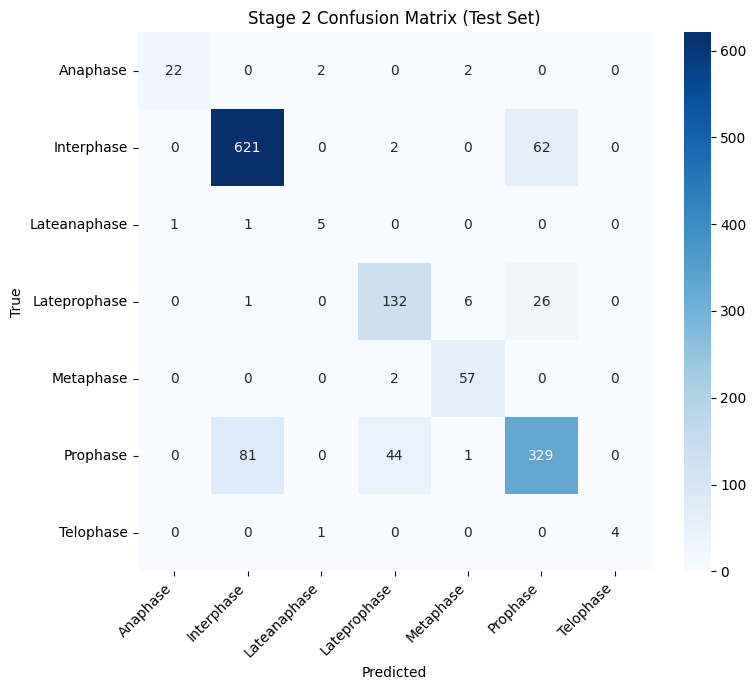

In [21]:
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Load the best checkpoint for final evaluation
best_ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(best_ckpt["model_state"])
model.eval()

all_logits, all_targets = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits = model(x)
        all_logits.append(logits.cpu())
        all_targets.append(y)

all_logits = torch.cat(all_logits)
all_probs = F.softmax(all_logits, dim=1).numpy()
y_true = torch.cat(all_targets).numpy()
y_pred = all_probs.argmax(1)

test_acc = accuracy_score(y_true, y_pred)
test_precision_macro = precision_score(y_true, y_pred, average="macro")
test_precision_per_class = precision_score(y_true, y_pred, average=None)
test_recall_macro = recall_score(y_true, y_pred, average="macro")
test_f1_macro = f1_score(y_true, y_pred, average="macro")

print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Test Precision (macro): {test_precision_macro:.4f}")
print(f"Test Recall (macro)  : {test_recall_macro:.4f}")
print(f"Test F1 (macro)      : {test_f1_macro:.4f}")
print()
print("Per-class precision:")
for cname, p in zip(CLASS_NAMES, test_precision_per_class):
    print(f"  {cname:15s}: {p:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 7))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Stage 2 Confusion Matrix (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Macro AUC: 0.9694
Micro AUC: 0.9810

Per-class AUC:
  Anaphase       : 0.9686
  Interphase     : 0.9526
  Lateanaphase   : 0.9964
  Lateprophase   : 0.9635
  Metaphase      : 0.9976
  Prophase       : 0.9053
  Telophase      : 0.9996


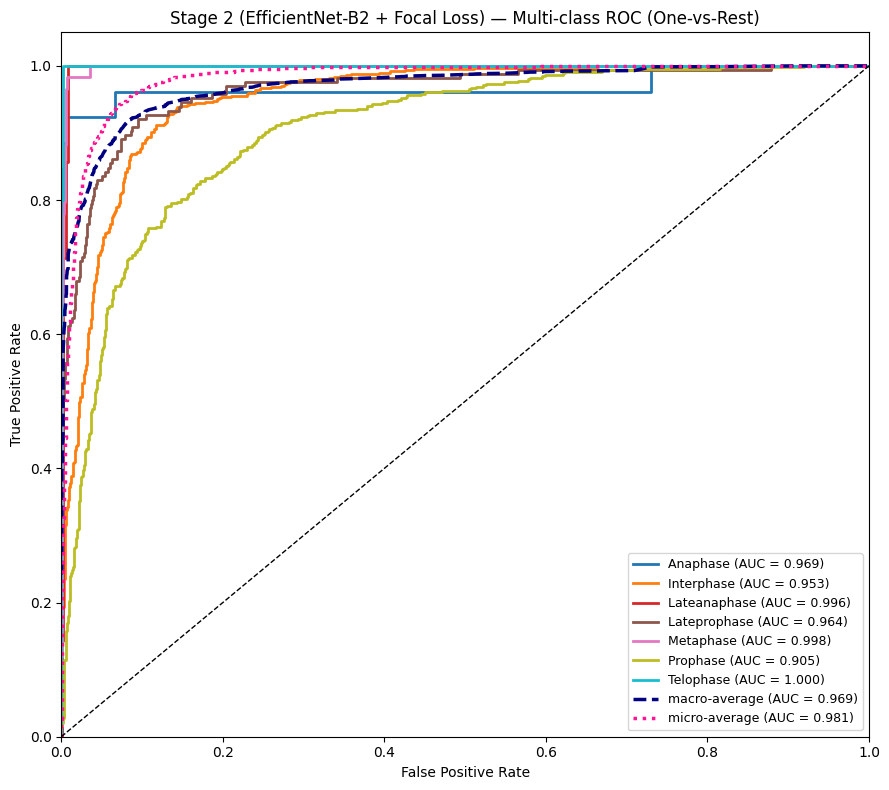

In [23]:
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average (pools all classes together)
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average (average of per-class curves)
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= NUM_CLASSES
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

print(f"Macro AUC: {roc_auc['macro']:.4f}")
print(f"Micro AUC: {roc_auc['micro']:.4f}")
print()
print("Per-class AUC:")
for i, cname in enumerate(CLASS_NAMES):
    print(f"  {cname:15s}: {roc_auc[i]:.4f}")

plt.figure(figsize=(9, 8))
colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
for i, (cname, color) in enumerate(zip(CLASS_NAMES, colors)):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
              label=f"{cname} (AUC = {roc_auc[i]:.3f})")

plt.plot(fpr["macro"], tpr["macro"], color="navy", linestyle="--", lw=2.5,
          label=f"macro-average (AUC = {roc_auc['macro']:.3f})")
plt.plot(fpr["micro"], tpr["micro"], color="deeppink", linestyle=":", lw=2.5,
          label=f"micro-average (AUC = {roc_auc['micro']:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Stage 2 (EfficientNet-B2 + Focal Loss) — Multi-class ROC (One-vs-Rest)")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


In [31]:
import numpy as np
import pandas as pd

# ── Confidence = max softmax probability per prediction ──
confidences = all_probs.max(axis=1)          # (N,) — model's confidence in its predicted class
predicted_classes = all_probs.argmax(axis=1)  # same as y_pred

# ============================================================
# 1. Average confidence PER PREDICTED CLASS
#    "When the model predicts Prophase, how confident is it on average?"
# ============================================================
print("=" * 60)
print("Average confidence when model PREDICTS each phase")
print("=" * 60)
pred_conf_rows = []
for cls_idx, cname in enumerate(CLASS_NAMES):
    mask = predicted_classes == cls_idx
    n = mask.sum()
    if n == 0:
        avg_conf, min_conf, max_conf = float("nan"), float("nan"), float("nan")
    else:
        avg_conf = confidences[mask].mean()
        min_conf = confidences[mask].min()
        max_conf = confidences[mask].max()
    pred_conf_rows.append([cname, n, avg_conf, min_conf, max_conf])
    print(f"  {cname:15s}: n={n:4d}  avg={avg_conf:.4f}  min={min_conf:.4f}  max={max_conf:.4f}")

# ============================================================
# 2. Average confidence PER TRUE CLASS, split by correct/incorrect
#    "When the true label is Lateprophase, how confident is the model —
#     and is it more/less confident when it gets it wrong?"
# ============================================================
print()
print("=" * 60)
print("Average confidence PER TRUE CLASS (correct vs incorrect predictions)")
print("=" * 60)
true_conf_rows = []
for cls_idx, cname in enumerate(CLASS_NAMES):
    mask = y_true == cls_idx
    n = mask.sum()
    correct_mask = mask & (y_pred == y_true)
    wrong_mask = mask & (y_pred != y_true)

    correct_conf = confidences[correct_mask].mean() if correct_mask.sum() > 0 else float("nan")
    wrong_conf = confidences[wrong_mask].mean() if wrong_mask.sum() > 0 else float("nan")
    overall_conf = confidences[mask].mean() if n > 0 else float("nan")

    true_conf_rows.append([cname, n, correct_mask.sum(), wrong_mask.sum(),
                            overall_conf, correct_conf, wrong_conf])
    print(f"  {cname:15s}: n={n:4d}  overall_avg={overall_conf:.4f}  "
          f"correct_avg={correct_conf:.4f} (n={correct_mask.sum()})  "
          f"wrong_avg={wrong_conf:.4f} (n={wrong_mask.sum()})")

# ============================================================
# 3. Full confidence matrix: average predicted probability for
#    EVERY (true class, predicted-as class) pair — shows exactly
#    how confidently Prophase gets mistaken for Lateprophase, etc.
# ============================================================
print()
print("=" * 60)
print("Mean predicted probability matrix (rows=true class, cols=phase probability)")
print("=" * 60)
conf_matrix = np.zeros((len(CLASS_NAMES), len(CLASS_NAMES)))
for cls_idx in range(len(CLASS_NAMES)):
    mask = y_true == cls_idx
    if mask.sum() > 0:
        conf_matrix[cls_idx] = all_probs[mask].mean(axis=0)

conf_df = pd.DataFrame(conf_matrix, index=CLASS_NAMES, columns=CLASS_NAMES)
print(conf_df.round(4))

# ============================================================
# 4. Summary DataFrames (for saving to CSV / including in the paper)
# ============================================================
pred_conf_df = pd.DataFrame(
    pred_conf_rows, columns=["phase", "n_predicted", "avg_confidence", "min_confidence", "max_confidence"]
)
true_conf_df = pd.DataFrame(
    true_conf_rows,
    columns=["phase", "n_true", "n_correct", "n_wrong", "avg_conf_overall", "avg_conf_correct", "avg_conf_wrong"]
)

print()
print("Saved DataFrames: pred_conf_df, true_conf_df, conf_df")
# Optional: save for the manuscript
# pred_conf_df.to_csv("per_class_confidence_by_prediction.csv", index=False)
# true_conf_df.to_csv("per_class_confidence_by_true_label.csv", index=False)
# conf_df.to_csv("mean_probability_matrix.csv")

Average confidence when model PREDICTS each phase
  Anaphase       : n=  23  avg=0.9177  min=0.5734  max=0.9972
  Interphase     : n= 704  avg=0.7651  min=0.3324  max=0.9812
  Lateanaphase   : n=   8  avg=0.8504  min=0.5247  max=0.9779
  Lateprophase   : n= 180  avg=0.7142  min=0.4899  max=0.9801
  Metaphase      : n=  66  avg=0.8953  min=0.4507  max=0.9970
  Prophase       : n= 417  avg=0.6821  min=0.4226  max=0.9535
  Telophase      : n=   4  avg=0.8674  min=0.7055  max=0.9978

Average confidence PER TRUE CLASS (correct vs incorrect predictions)
  Anaphase       : n=  26  overall_avg=0.9031  correct_avg=0.9147 (n=22)  wrong_avg=0.8396 (n=4)
  Interphase     : n= 685  overall_avg=0.7651  correct_avg=0.7797 (n=621)  wrong_avg=0.6232 (n=64)
  Lateanaphase   : n=   7  overall_avg=0.7520  correct_avg=0.7895 (n=5)  wrong_avg=0.6581 (n=2)
  Lateprophase   : n= 165  overall_avg=0.7394  correct_avg=0.7587 (n=132)  wrong_avg=0.6621 (n=33)
  Metaphase      : n=  59  overall_avg=0.8998  correct_

In [37]:
import os
print(os.path.exists(CONFIG["stage1_weights"]))

False


In [47]:
import torch
import torch.nn.functional as F
from torchvision import transforms

@torch.no_grad()
def classify_crop(crop_bgr, stage2_model, tfms=eval_tfms, device=DEVICE):
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    tensor = tfms(transforms.functional.to_pil_image(crop_rgb)).unsqueeze(0).to(device)
    logits = stage2_model(tensor)
    probs = F.softmax(logits, dim=1).cpu().numpy()[0]
    pred_idx = int(probs.argmax())
    return CLASS_NAMES[pred_idx], probs


Cell #0  |  Detection conf: 0.9515  |  Predicted: Prophase (0.8855)
  Per-phase confidence:
    Prophase       : 0.8855  ██████████████████████████ <-- predicted
    Interphase     : 0.0772  ██
    Lateprophase   : 0.0373  █
    Metaphase      : 0.0001  
    Telophase      : 0.0000  
    Anaphase       : 0.0000  
    Lateanaphase   : 0.0000  

Cell #1  |  Detection conf: 0.9505  |  Predicted: Interphase (0.8268)
  Per-phase confidence:
    Interphase     : 0.8268  ████████████████████████ <-- predicted
    Prophase       : 0.1732  █████
    Metaphase      : 0.0000  
    Lateprophase   : 0.0000  
    Telophase      : 0.0000  
    Anaphase       : 0.0000  
    Lateanaphase   : 0.0000  

Cell #2  |  Detection conf: 0.9500  |  Predicted: Prophase (0.6457)
  Per-phase confidence:
    Prophase       : 0.6457  ███████████████████ <-- predicted
    Lateprophase   : 0.2861  ████████
    Interphase     : 0.0681  ██
    Anaphase       : 0.0001  
    Metaphase      : 0.0000  
    Telophase      :

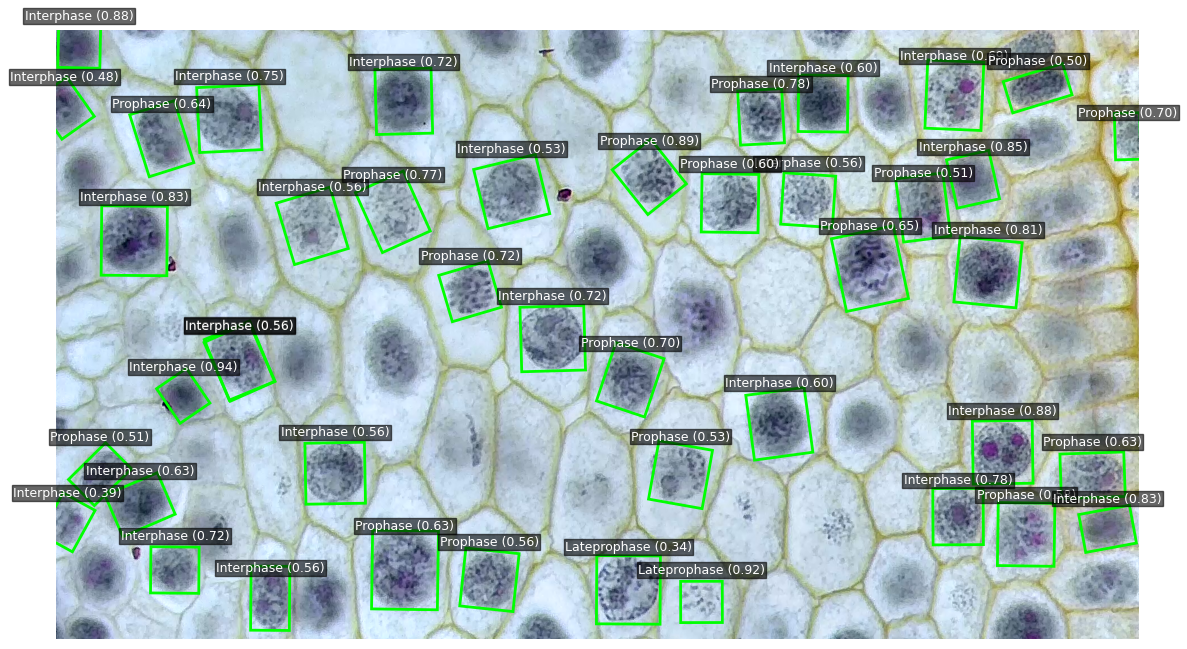

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# ============================================================
# Fix the path, THEN load Stage 1 model
# ============================================================
CONFIG["stage1_weights"] = r"C:\Users\ROG\runs_obb\obb_s_832_ep150\weights\best.pt"
stage1_model = YOLO(CONFIG["stage1_weights"])


def run_pipeline_with_confidence(image_path, stage2_model, conf=CONFIG["det_conf"], imgsz=CONFIG["det_imgsz"]):
    """
    Runs Stage 1 (YOLO-OBB detection) + Stage 2 (EfficientNet-B2 classification)
    on a single image, returning per-detection results with full per-phase
    confidence scores (not just the argmax prediction).
    """
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    results = stage1_model.predict(source=str(image_path), conf=conf, imgsz=imgsz, verbose=False)
    r = results[0]

    detections = []
    if r.obb is None or len(r.obb) == 0:
        print("No cells detected.")
        return detections

    xywhr = r.obb.xywhr.cpu().numpy()
    det_confs = r.obb.conf.cpu().numpy()

    for i, ((cx, cy, w, h, angle_rad), dconf) in enumerate(zip(xywhr, det_confs)):
        crop = rotate_and_crop(image, cx, cy, w, h, angle_rad, out_size=CONFIG["crop_size"])
        if crop is None:
            continue

        phase, probs = classify_crop(crop, stage2_model)

        detections.append({
            "id": i,
            "bbox_xywhr": (float(cx), float(cy), float(w), float(h), float(angle_rad)),
            "det_conf": float(dconf),
            "predicted_phase": phase,
            "predicted_confidence": float(probs.max()),
            "phase_confidences": {c: float(p) for c, p in zip(CLASS_NAMES, probs)},
        })

    return detections


def print_confidence_report(detections):
    """Prints a readable per-cell, per-phase confidence breakdown."""
    if not detections:
        print("No detections to report.")
        return
    for d in detections:
        print(f"\nCell #{d['id']}  |  Detection conf: {d['det_conf']:.4f}  "
              f"|  Predicted: {d['predicted_phase']} ({d['predicted_confidence']:.4f})")
        print("  Per-phase confidence:")
        sorted_probs = sorted(d["phase_confidences"].items(), key=lambda x: -x[1])
        for phase, p in sorted_probs:
            bar = "█" * int(p * 30)
            marker = " <-- predicted" if phase == d["predicted_phase"] else ""
            print(f"    {phase:15s}: {p:.4f}  {bar}{marker}")


def visualize_predictions(image_path, detections, save_path=None):
    """Draws bounding boxes + predicted phase + confidence on the image."""
    image = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, figsize=(12, 12))
    ax.imshow(image_rgb)

    for d in detections:
        cx, cy, w, h, angle_rad = d["bbox_xywhr"]
        angle_deg = np.degrees(angle_rad)

        rect = ((cx, cy), (w, h), angle_deg)
        box_pts = cv2.boxPoints(rect)

        polygon = plt.Polygon(box_pts, closed=True, edgecolor="lime", fill=False, linewidth=2)
        ax.add_patch(polygon)

        label = f"{d['predicted_phase']} ({d['predicted_confidence']:.2f})"
        ax.text(cx, cy - h / 2 - 8, label, color="white", fontsize=9,
                ha="center", va="bottom",
                bbox=dict(facecolor="black", alpha=0.6, pad=1))

    ax.axis("off")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved visualization to {save_path}")
    plt.show()


# ============================================================
# Usage — swap in any image path
# ============================================================
image_path = Path(r"C:\Users\ROG\Desktop\Datasets_with_annotation_object_detection\Merged_dataset\images\test\A_a1fc5d61-task-842_merged.png")

detections = run_pipeline_with_confidence(image_path, stage2_model=model)
print_confidence_report(detections)
visualize_predictions(image_path, detections)  # add save_path="output.png" to save it


Cell #0  |  Detection conf: 0.9494  |  Predicted: Interphase (0.9379)
  Per-phase confidence:
    Interphase     : 0.9379  ████████████████████████████ <-- predicted
    Prophase       : 0.0613  █
    Lateprophase   : 0.0006  
    Metaphase      : 0.0002  
    Telophase      : 0.0000  
    Lateanaphase   : 0.0000  
    Anaphase       : 0.0000  

Cell #1  |  Detection conf: 0.9485  |  Predicted: Interphase (0.9114)
  Per-phase confidence:
    Interphase     : 0.9114  ███████████████████████████ <-- predicted
    Prophase       : 0.0884  ██
    Lateprophase   : 0.0001  
    Telophase      : 0.0000  
    Metaphase      : 0.0000  
    Lateanaphase   : 0.0000  
    Anaphase       : 0.0000  

Cell #2  |  Detection conf: 0.9458  |  Predicted: Interphase (0.6553)
  Per-phase confidence:
    Interphase     : 0.6553  ███████████████████ <-- predicted
    Prophase       : 0.3446  ██████████
    Lateprophase   : 0.0001  
    Telophase      : 0.0000  
    Metaphase      : 0.0000  
    Lateanaphase

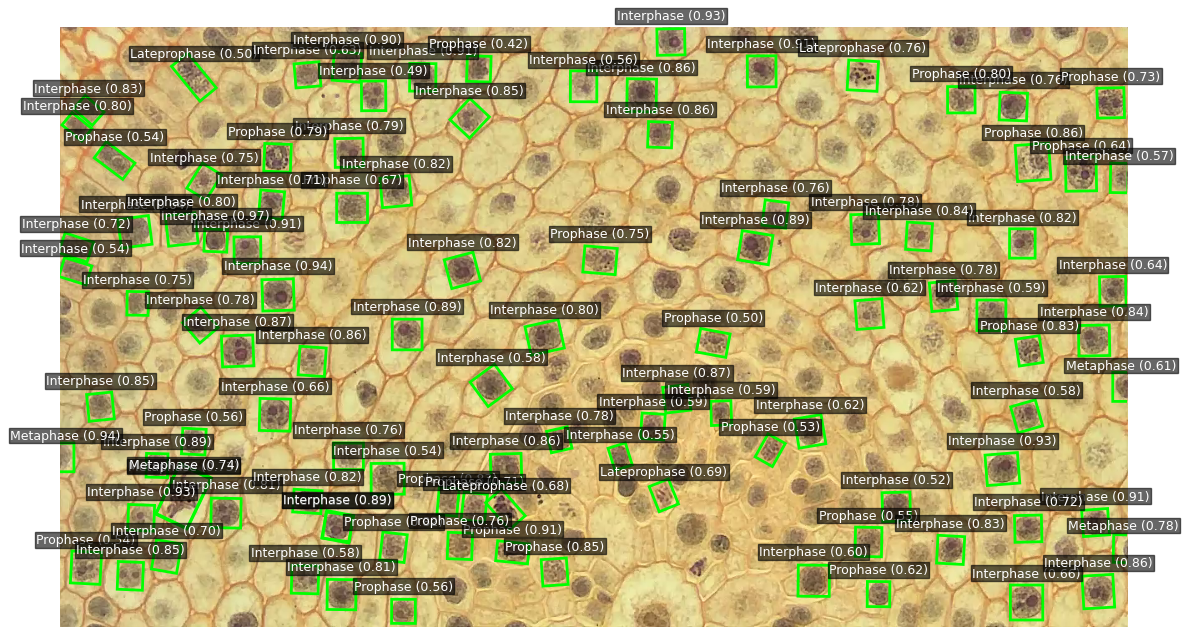

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# ============================================================
# Fix the path, THEN load Stage 1 model
# ============================================================
CONFIG["stage1_weights"] = r"C:\Users\ROG\runs_obb\obb_s_832_ep150\weights\best.pt"
stage1_model = YOLO(CONFIG["stage1_weights"])


def run_pipeline_with_confidence(image_path, stage2_model, conf=CONFIG["det_conf"], imgsz=CONFIG["det_imgsz"]):
    """
    Runs Stage 1 (YOLO-OBB detection) + Stage 2 (EfficientNet-B2 classification)
    on a single image, returning per-detection results with full per-phase
    confidence scores (not just the argmax prediction).
    """
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    results = stage1_model.predict(source=str(image_path), conf=conf, imgsz=imgsz, verbose=False)
    r = results[0]

    detections = []
    if r.obb is None or len(r.obb) == 0:
        print("No cells detected.")
        return detections

    xywhr = r.obb.xywhr.cpu().numpy()
    det_confs = r.obb.conf.cpu().numpy()

    for i, ((cx, cy, w, h, angle_rad), dconf) in enumerate(zip(xywhr, det_confs)):
        crop = rotate_and_crop(image, cx, cy, w, h, angle_rad, out_size=CONFIG["crop_size"])
        if crop is None:
            continue

        phase, probs = classify_crop(crop, stage2_model)

        detections.append({
            "id": i,
            "bbox_xywhr": (float(cx), float(cy), float(w), float(h), float(angle_rad)),
            "det_conf": float(dconf),
            "predicted_phase": phase,
            "predicted_confidence": float(probs.max()),
            "phase_confidences": {c: float(p) for c, p in zip(CLASS_NAMES, probs)},
        })

    return detections


def print_confidence_report(detections):
    """Prints a readable per-cell, per-phase confidence breakdown."""
    if not detections:
        print("No detections to report.")
        return
    for d in detections:
        print(f"\nCell #{d['id']}  |  Detection conf: {d['det_conf']:.4f}  "
              f"|  Predicted: {d['predicted_phase']} ({d['predicted_confidence']:.4f})")
        print("  Per-phase confidence:")
        sorted_probs = sorted(d["phase_confidences"].items(), key=lambda x: -x[1])
        for phase, p in sorted_probs:
            bar = "█" * int(p * 30)
            marker = " <-- predicted" if phase == d["predicted_phase"] else ""
            print(f"    {phase:15s}: {p:.4f}  {bar}{marker}")


def visualize_predictions(image_path, detections, save_path=None):
    """Draws bounding boxes + predicted phase + confidence on the image."""
    image = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, figsize=(12, 12))
    ax.imshow(image_rgb)

    for d in detections:
        cx, cy, w, h, angle_rad = d["bbox_xywhr"]
        angle_deg = np.degrees(angle_rad)

        rect = ((cx, cy), (w, h), angle_deg)
        box_pts = cv2.boxPoints(rect)

        polygon = plt.Polygon(box_pts, closed=True, edgecolor="lime", fill=False, linewidth=2)
        ax.add_patch(polygon)

        label = f"{d['predicted_phase']} ({d['predicted_confidence']:.2f})"
        ax.text(cx, cy - h / 2 - 8, label, color="white", fontsize=9,
                ha="center", va="bottom",
                bbox=dict(facecolor="black", alpha=0.6, pad=1))

    ax.axis("off")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved visualization to {save_path}")
    plt.show()


# ============================================================
# Usage — swap in any image path
# ============================================================
image_path = Path(r"C:\Users\ROG\Desktop\Datasets_with_annotation_object_detection\Merged_dataset\images\val\A_c17c8125-task-1035_merged.png")

detections = run_pipeline_with_confidence(image_path, stage2_model=model)
print_confidence_report(detections)
visualize_predictions(image_path, detections)  # add save_path="output.png" to save it


Cell #0  |  Detection conf: 0.9494  |  Predicted: Interphase (0.9379)
  Per-phase confidence:
    Interphase     : 0.9379  ████████████████████████████ <-- predicted
    Prophase       : 0.0613  █
    Lateprophase   : 0.0006  
    Metaphase      : 0.0002  
    Telophase      : 0.0000  
    Lateanaphase   : 0.0000  
    Anaphase       : 0.0000  

Cell #1  |  Detection conf: 0.9485  |  Predicted: Interphase (0.9114)
  Per-phase confidence:
    Interphase     : 0.9114  ███████████████████████████ <-- predicted
    Prophase       : 0.0884  ██
    Lateprophase   : 0.0001  
    Telophase      : 0.0000  
    Metaphase      : 0.0000  
    Lateanaphase   : 0.0000  
    Anaphase       : 0.0000  

Cell #2  |  Detection conf: 0.9458  |  Predicted: Interphase (0.6553)
  Per-phase confidence:
    Interphase     : 0.6553  ███████████████████ <-- predicted
    Prophase       : 0.3446  ██████████
    Lateprophase   : 0.0001  
    Telophase      : 0.0000  
    Metaphase      : 0.0000  
    Lateanaphase

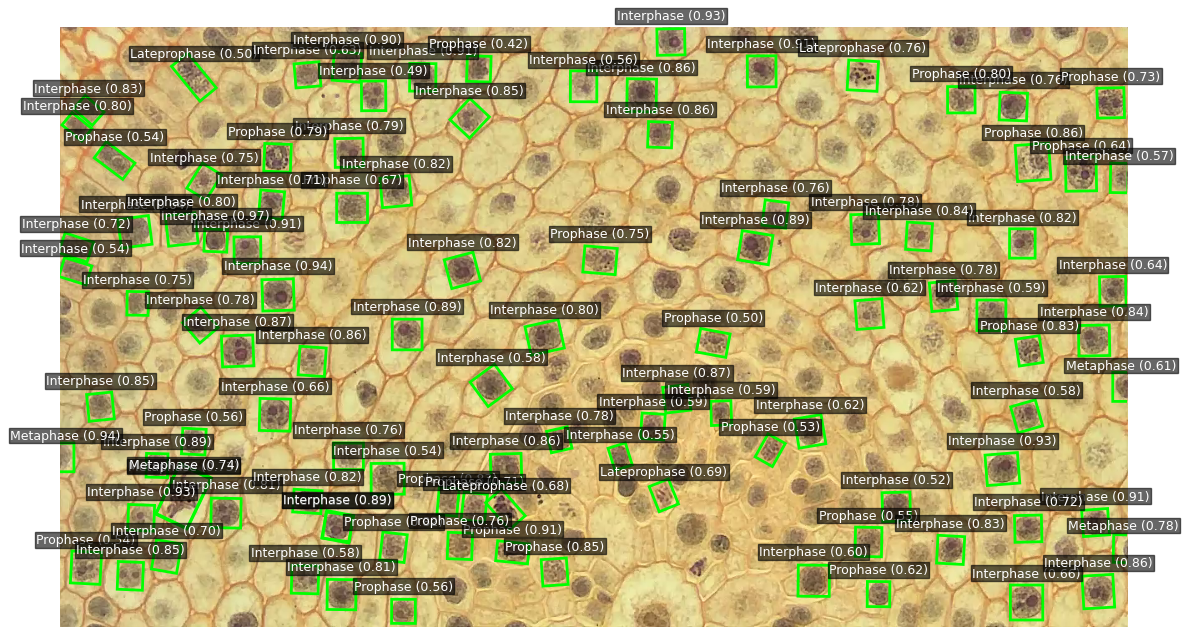

In [53]:
# ============================================================
# Usage — swap in any image path
# ============================================================
image_path = Path(r"C:\Users\ROG\Desktop\Datasets_with_annotation_object_detection\Merged_dataset\images\val\A_c17c8125-task-1035_merged.png")

# Designated output path — change this to wherever you want it saved
output_path = r"C:\Users\ROG\Desktop\Datasets_with_annotation_object_detection\pipeline_outputs\A_c17c8125-task-1035_merged_pred.png"

# Make sure the output directory exists
Path(output_path).parent.mkdir(parents=True, exist_ok=True)

detections = run_pipeline_with_confidence(image_path, stage2_model=model)
print_confidence_report(detections)
visualize_predictions(image_path, detections, save_path=output_path)

In [55]:
# ── Add BEFORE your training loop ──
history = {
    "train_loss": [], "train_acc": [], "train_f1": [],
    "val_loss": [], "val_acc": [], "val_f1": [],
}

for epoch in range(start_epoch, CONFIG["epochs"]):
    t0 = time.time()
    train_loss, train_acc, train_f1 = run_epoch(train_loader, train=True)
    val_loss, val_acc, val_f1 = run_epoch(val_loader, train=False)
    scheduler.step()

    # ── Record history ──
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch+1:03d}/{CONFIG['epochs']} "
          f"| train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} "
          f"| val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} "
          f"| {time.time()-t0:.1f}s")

    ckpt = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict(),
        "sched_state": scheduler.state_dict(),
        "best_val_f1": max(best_val_f1, val_f1),
        "history": history,   # ← save history INSIDE the checkpoint too, so resume doesn't lose it
    }
    torch.save(ckpt, ckpt_path)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(ckpt, best_ckpt_path)
        print(f"  -> new best (val macro-F1 = {best_val_f1:.4f}), saved to {best_ckpt_path}")

print("Training complete. Best val macro-F1:", best_val_f1)

# If resuming, also restore history:
# if CONFIG["resume"] and os.path.exists(ckpt_path):
#     ckpt = torch.load(ckpt_path, map_location=DEVICE)
#     history = ckpt.get("history", history)

Training complete. Best val macro-F1: 0.8897318039380859


In [57]:
import re

# Paste your full printed training log here (or read from a saved .txt/.log file)
log_text = """
Epoch 001/40 | train loss 1.2345 acc 0.4500 f1 0.4200 | val loss 1.1000 acc 0.4800 f1 0.4500 | 12.3s
Epoch 002/40 | train loss 1.0123 acc 0.5200 f1 0.5000 | val loss 0.9800 acc 0.5300 f1 0.5100 | 11.9s
...
"""

pattern = re.compile(
    r"train loss ([\d.]+) acc ([\d.]+) f1 ([\d.]+) \| val loss ([\d.]+) acc ([\d.]+) f1 ([\d.]+)"
)

history = {"train_loss": [], "train_acc": [], "train_f1": [],
           "val_loss": [], "val_acc": [], "val_f1": []}

for match in pattern.finditer(log_text):
    tl, ta, tf1, vl, va, vf1 = map(float, match.groups())
    history["train_loss"].append(tl)
    history["train_acc"].append(ta)
    history["train_f1"].append(tf1)
    history["val_loss"].append(vl)
    history["val_acc"].append(va)
    history["val_f1"].append(vf1)

print(f"Parsed {len(history['train_loss'])} epochs")

Parsed 2 epochs


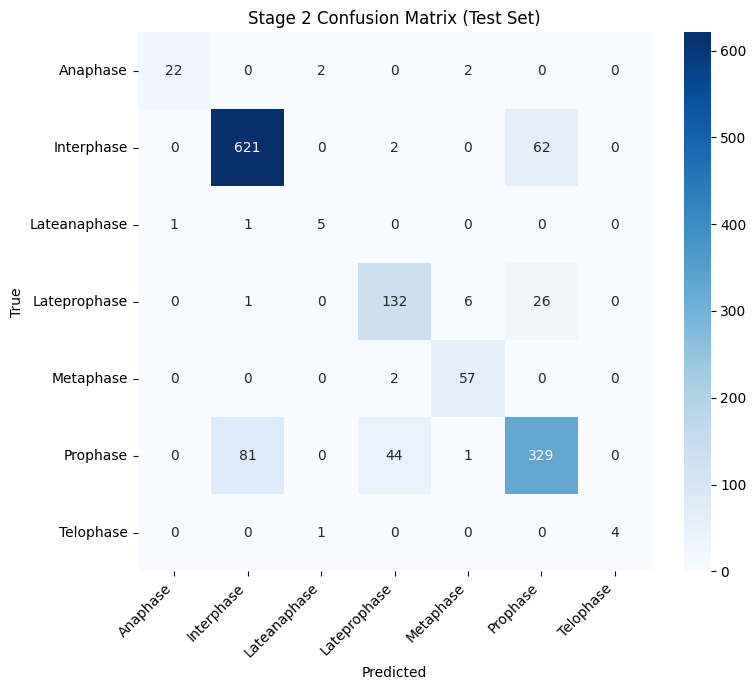

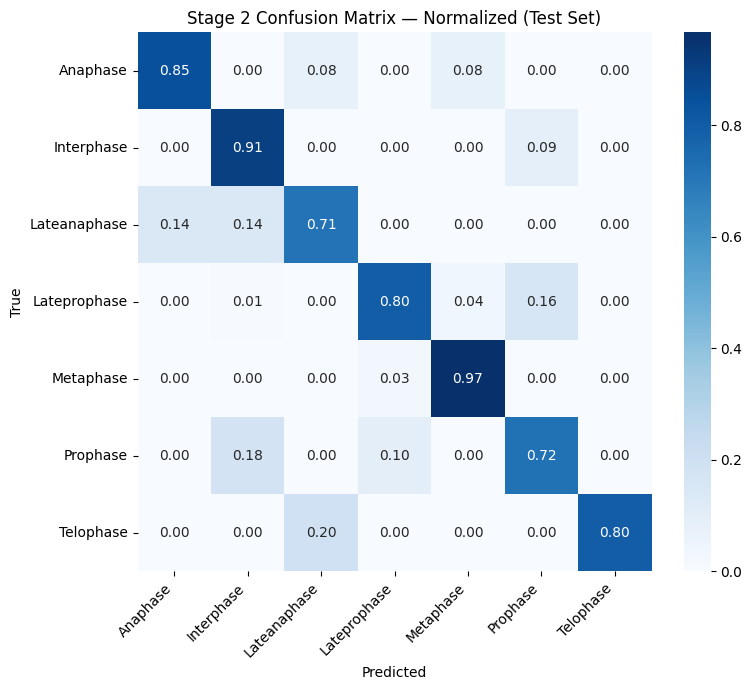

In [61]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Stage 2 Confusion Matrix (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

# Normalized version (row-wise %, easier to spot systematic confusion like Prophase/Lateprophase)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(8, 7))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Stage 2 Confusion Matrix — Normalized (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix_normalized.png", dpi=200, bbox_inches="tight")
plt.show()

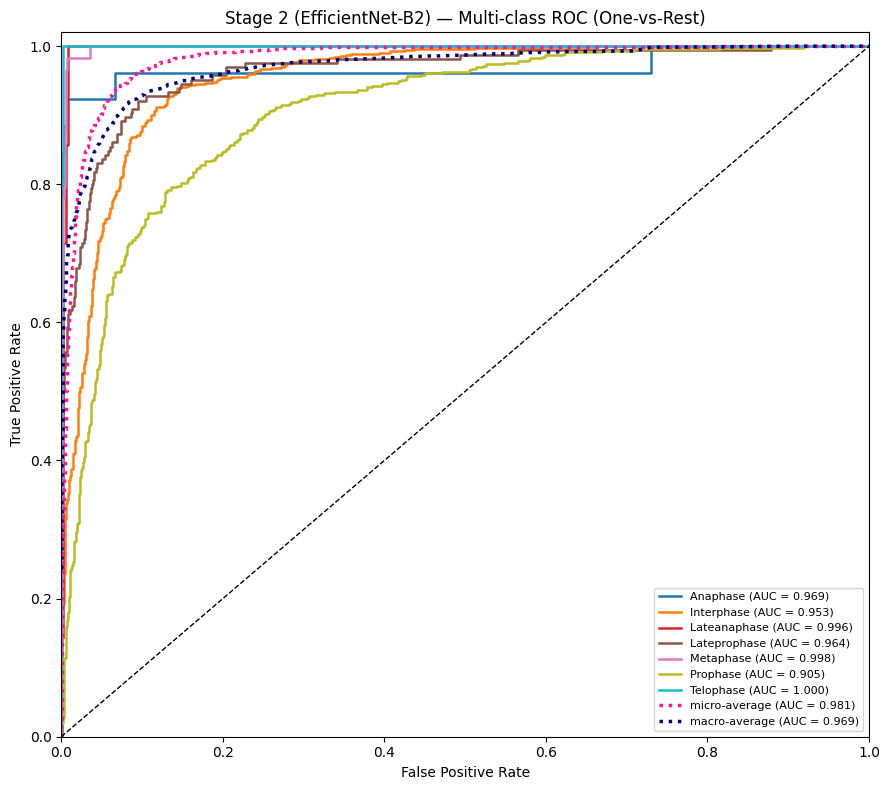

Per-class AUC:
  Anaphase       : 0.9686
  Interphase     : 0.9526
  Lateanaphase   : 0.9964
  Lateprophase   : 0.9635
  Metaphase      : 0.9976
  Prophase       : 0.9053
  Telophase      : 0.9996


In [63]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

n_classes = len(CLASS_NAMES)
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))  # (N, n_classes)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(9, 8))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=1.8,
              label=f"{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.3f})")

plt.plot(fpr["micro"], tpr["micro"], color="deeppink", linestyle=":", lw=2.5,
          label=f"micro-average (AUC = {roc_auc['micro']:.3f})")
plt.plot(fpr["macro"], tpr["macro"], color="navy", linestyle=":", lw=2.5,
          label=f"macro-average (AUC = {roc_auc['macro']:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0, 1]); plt.ylim([0, 1.02])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Stage 2 (EfficientNet-B2) — Multi-class ROC (One-vs-Rest)")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print("Per-class AUC:")
for i, cname in enumerate(CLASS_NAMES):
    print(f"  {cname:15s}: {roc_auc[i]:.4f}")

In [66]:
from sklearn.metrics import f1_score, accuracy_score

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []

    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)

            if train:
                optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                logits = model(x)
                loss = criterion(logits, y)

            if train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * x.size(0)
            all_preds.append(logits.argmax(1).detach().cpu())
            all_targets.append(y.detach().cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    avg_loss = total_loss / len(loader.dataset)
    f1_macro = f1_score(all_targets, all_preds, average="macro")
    acc = accuracy_score(all_targets, all_preds)
    f1_per_class = f1_score(all_targets, all_preds, average=None, labels=list(range(len(CLASS_NAMES))))
    return avg_loss, acc, f1_macro, f1_per_class

In [68]:
import time

history = {
    "train_loss": [], "val_loss": [],
    "val_acc": [], "val_f1_macro": [],
    "val_f1_per_class": [],   # list of arrays, one per epoch
}

for epoch in range(start_epoch, CONFIG["epochs"]):
    t0 = time.time()
    train_loss, train_acc, train_f1, _ = run_epoch(train_loader, train=True)
    val_loss, val_acc, val_f1, val_f1_pc = run_epoch(val_loader, train=False)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1_macro"].append(val_f1)
    history["val_f1_per_class"].append(val_f1_pc)

    print(f"Epoch {epoch+1:03d}/{CONFIG['epochs']} "
          f"| train loss {train_loss:.4f} "
          f"| val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} "
          f"| {time.time()-t0:.1f}s")

    ckpt = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict(),
        "sched_state": scheduler.state_dict(),
        "best_val_f1": max(best_val_f1, val_f1),
        "history": history,
    }
    torch.save(ckpt, ckpt_path)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(ckpt, best_ckpt_path)
        print(f"  -> new best (val macro-F1 = {best_val_f1:.4f}), saved to {best_ckpt_path}")

print("Training complete. Best val macro-F1:", best_val_f1)

Training complete. Best val macro-F1: 0.8897318039380859


In [76]:
print("CONFIG['epochs']:", CONFIG["epochs"])
print("start_epoch:", start_epoch)
print("best_val_f1:", best_val_f1)
print("checkpoint exists:", os.path.exists(ckpt_path))

if os.path.exists(ckpt_path):
    ckpt_check = torch.load(ckpt_path, map_location=DEVICE)
    print("Keys in checkpoint:", list(ckpt_check.keys()))
    print("Epoch stored in checkpoint:", ckpt_check.get("epoch"))
    print("Has 'history' key:", "history" in ckpt_check)
    if "history" in ckpt_check:
        print("Epochs recorded in checkpoint history:", len(ckpt_check["history"]["train_loss"]))

CONFIG['epochs']: 40
start_epoch: 40
best_val_f1: 0.8897318039380859
checkpoint exists: True
Keys in checkpoint: ['epoch', 'model_state', 'optim_state', 'sched_state', 'best_val_f1']
Epoch stored in checkpoint: 39
Has 'history' key: False


In [74]:
import os, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score

# ============================================================
# 1. run_epoch — now returns per-class F1 too
# ============================================================
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []

    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)

            if train:
                optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                logits = model(x)
                loss = criterion(logits, y)

            if train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * x.size(0)
            all_preds.append(logits.argmax(1).detach().cpu())
            all_targets.append(y.detach().cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    avg_loss = total_loss / len(loader.dataset)
    f1_macro = f1_score(all_targets, all_preds, average="macro")
    acc = accuracy_score(all_targets, all_preds)
    f1_per_class = f1_score(all_targets, all_preds, average=None,
                             labels=list(range(len(CLASS_NAMES))))
    return avg_loss, acc, f1_macro, f1_per_class


# ============================================================
# 2. Checkpoint paths + resume (including history restoration)
# ============================================================
ckpt_path = os.path.join(CONFIG["checkpoint_dir"], "last.pt")
best_ckpt_path = os.path.join(CONFIG["checkpoint_dir"], "best.pt")

start_epoch = 0
best_val_f1 = -1.0
history = {
    "train_loss": [], "val_loss": [],
    "val_acc": [], "val_f1_macro": [],
    "val_f1_per_class": [],
}

if CONFIG["resume"] and os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optim_state"])
    scheduler.load_state_dict(ckpt["sched_state"])
    start_epoch = ckpt["epoch"] + 1
    best_val_f1 = ckpt.get("best_val_f1", -1.0)
    history = ckpt.get("history", history)
    print("Resumed from epoch", start_epoch, "- history has",
          len(history["val_f1_per_class"]), "epochs recorded.")

# ============================================================
# 3. Training loop
# ============================================================
if start_epoch >= CONFIG["epochs"]:
    print("start_epoch (", start_epoch, ") >= CONFIG epochs (", CONFIG["epochs"], ")")
    print("Training loop will NOT run. Increase CONFIG epochs, or proceed to plotting with restored history.")

for epoch in range(start_epoch, CONFIG["epochs"]):
    t0 = time.time()
    train_loss, train_acc, train_f1, _ = run_epoch(train_loader, train=True)
    val_loss, val_acc, val_f1, val_f1_pc = run_epoch(val_loader, train=False)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1_macro"].append(val_f1)
    history["val_f1_per_class"].append(val_f1_pc)

    print(f"Epoch {epoch+1:03d}/{CONFIG['epochs']} "
          f"| train loss {train_loss:.4f} "
          f"| val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} "
          f"| {time.time()-t0:.1f}s")

    ckpt = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict(),
        "sched_state": scheduler.state_dict(),
        "best_val_f1": max(best_val_f1, val_f1),
        "history": history,
    }
    torch.save(ckpt, ckpt_path)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(ckpt, best_ckpt_path)
        print("  -> new best (val macro-F1 =", round(best_val_f1, 4), "), saved to", best_ckpt_path)

print("Training complete. Best val macro-F1:", best_val_f1)

# ============================================================
# 4. Guarded plotting
# ============================================================
f1_per_class_list = history["val_f1_per_class"]

if len(f1_per_class_list) == 0:
    msg = (
        "history val_f1_per_class is empty - no epochs were recorded. "
        "Check that CONFIG epochs is greater than start_epoch, or that resume "
        "correctly restored a checkpoint with saved history."
    )
    raise ValueError(msg)

shapes = set(np.array(e).shape for e in f1_per_class_list)
if len(shapes) > 1:
    msg = (
        "Inconsistent per-class F1 shapes across epochs: " + str(shapes) + ". "
        "This usually means some epochs were recorded with an older run_epoch "
        "that did not return per-class F1. Retrain from scratch with the "
        "updated run_epoch in place from epoch 0."
    )
    raise ValueError(msg)

f1_per_class_arr = np.array(f1_per_class_list)
print("f1_per_class_arr shape:", f1_per_class_arr.shape)

epochs_range = range(1, len(history["train_loss"]) + 1)

classes_to_track = ["Prophase", "Lateprophase", "Telophase"]
track_colors = {"Prophase": "tab:blue", "Lateprophase": "tab:orange", "Telophase": "tab:green"}
target_f1 = 0.80

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train", color="tab:blue")
axes[0].plot(epochs_range, history["val_loss"], label="Val", color="tab:orange")
axes[0].set_xlabel("Epoch"); axes[0].set_title("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["val_f1_macro"], label="Macro F1", color="tab:blue")
axes[1].plot(epochs_range, history["val_acc"], label="Accuracy", color="tab:orange")
axes[1].set_xlabel("Epoch"); axes[1].set_title("Validation metrics")
axes[1].legend(); axes[1].grid(alpha=0.3)

for cname in classes_to_track:
    idx = CLASS_NAMES.index(cname)
    axes[2].plot(epochs_range, f1_per_class_arr[:, idx],
                 label=cname, color=track_colors.get(cname))
axes[2].axhline(target_f1, color="gray", linestyle="--", linewidth=1, label="Target 0.80")
axes[2].set_xlabel("Epoch"); axes[2].set_title("Class F1 tracking")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle("Fig. XI. The suggested EfficientNet-B2 classifier's training curves.", fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig("training_summary_figure.png", dpi=300, bbox_inches="tight")
plt.show()

Resumed from epoch 40 - history has 0 epochs recorded.
start_epoch ( 40 ) >= CONFIG epochs ( 40 )
Training loop will NOT run. Increase CONFIG epochs, or proceed to plotting with restored history.
Training complete. Best val macro-F1: 0.8897318039380859


ValueError: history val_f1_per_class is empty - no epochs were recorded. Check that CONFIG epochs is greater than start_epoch, or that resume correctly restored a checkpoint with saved history.